In [58]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [59]:
# CAMBIA esto solo si tu zip tiene otro nombre
ZIP_PATH = "/content/drive/MyDrive/UCMerced_64-20260108T171202Z-1-001.zip"

# Descomprime en /content
!unzip -qo "$ZIP_PATH" -d /content/

import os
print("Contenido de /content:")
print(os.listdir("/content")[:20])

print("\n¿Existe la carpeta del dataset?")
print(os.path.exists("/content/UCMerced_64"))

Contenido de /content:
['.config', 'UCMerced_32', 'drive', 'UCMerced_64', 'UCMerced_128', 'sample_data']

¿Existe la carpeta del dataset?
True


In [60]:
import os
import math
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

import tensorflow as tf
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split

print("TensorFlow:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices('GPU'))

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

DATASET_PATH = "/content/UCMerced_64"

N_CLASSES = 21
IMG_SIZE = (256, 256)
PATCH_INPUT_SIZE = (224, 224)
ALPHA_PATCHES = 9
MAX_PATCH_TRIALS = 400

RUN_MODE = "full"   # <-- aquí cambias entre "debug" y "full"

if RUN_MODE == "debug":
    N_FOLDS = 2
    EPOCHS = 10
    MAX_TRAIN_IMAGES_PER_FOLD = 420
    MAX_TEST_IMAGES_PER_FOLD = 210
elif RUN_MODE == "full":
    N_FOLDS = 5
    EPOCHS = 20
    MAX_TRAIN_IMAGES_PER_FOLD = None
    MAX_TEST_IMAGES_PER_FOLD = None
else:
    raise ValueError("RUN_MODE debe ser 'debug' o 'full'")

BATCH_SIZE = 32
LR = 1e-2
L2_LAMBDA = 1e-4
BETA_ANTI = 1e-3

FEATURE_CACHE = {}

print("Configuración activa:")
print("RUN_MODE =", RUN_MODE)
print("N_FOLDS =", N_FOLDS)
print("EPOCHS =", EPOCHS)
print("MAX_TRAIN_IMAGES_PER_FOLD =", MAX_TRAIN_IMAGES_PER_FOLD)
print("MAX_TEST_IMAGES_PER_FOLD =", MAX_TEST_IMAGES_PER_FOLD)

TensorFlow: 2.19.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Configuración activa:
RUN_MODE = full
N_FOLDS = 5
EPOCHS = 20
MAX_TRAIN_IMAGES_PER_FOLD = None
MAX_TEST_IMAGES_PER_FOLD = None


In [61]:
def load_ucmerced(dataset_path):
    if not os.path.isdir(dataset_path):
        raise FileNotFoundError(f"No existe la ruta:\n{dataset_path}")

    images, labels = [], []
    class_names = []

    folders = sorted([
        d for d in os.listdir(dataset_path)
        if os.path.isdir(os.path.join(dataset_path, d))
    ])

    print("Carpetas encontradas:", len(folders))

    for idx, cls in enumerate(folders):
        class_names.append(cls)
        cls_path = os.path.join(dataset_path, cls)

        for fname in sorted(os.listdir(cls_path)):
            fpath = os.path.join(cls_path, fname)
            try:
                img = Image.open(fpath).convert("RGB").resize(IMG_SIZE)
                images.append(np.array(img, dtype=np.uint8))
                labels.append(idx)
            except Exception as e:
                print(f"Error leyendo {fpath}: {e}")

    images = np.asarray(images, dtype=np.uint8)
    labels = np.asarray(labels, dtype=np.int32)

    return images, labels, class_names


images, labels, class_names = load_ucmerced(DATASET_PATH)

print("Número de imágenes:", len(images))
print("Número de clases:", len(class_names))
print("Shape imágenes:", images.shape)
print("Primeras clases:", class_names[:5])

Carpetas encontradas: 21
Número de imágenes: 2100
Número de clases: 21
Shape imágenes: (2100, 256, 256, 3)
Primeras clases: ['agricultural', 'airplane', 'baseballdiamond', 'beach', 'buildings']


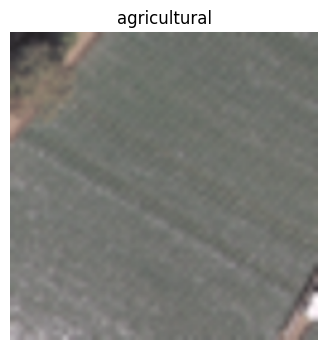

In [62]:
plt.figure(figsize=(4, 4))
plt.imshow(images[0])
plt.title(class_names[labels[0]])
plt.axis("off")
plt.show()

In [63]:
# %% [5] SALIENCY MAP
def compute_saliency_map(img_uint8):
    img = tf.convert_to_tensor(img_uint8[np.newaxis, ...], dtype=tf.float32) / 255.0
    gray = tf.image.rgb_to_grayscale(img)
    sobel = tf.image.sobel_edges(gray)
    gx = sobel[..., 0]
    gy = sobel[..., 1]
    mag = tf.sqrt(tf.square(gx) + tf.square(gy))
    mag = tf.nn.avg_pool2d(mag, ksize=7, strides=1, padding="SAME")
    sal = mag[0, ..., 0].numpy()
    sal = sal - sal.min()
    sal = sal / (sal.max() + 1e-8)
    return sal.astype(np.float32)

def get_salient_region_bbox(saliency, threshold=0.35):
    mask = saliency >= threshold

    if mask.sum() == 0:
        thr = np.percentile(saliency, 80)
        mask = saliency >= thr

    ys, xs = np.where(mask)
    if len(xs) == 0 or len(ys) == 0:
        h, w = saliency.shape
        return 0, 0, w, h

    return xs.min(), ys.min(), xs.max() + 1, ys.max() + 1
    return xs.min(), ys.min(), xs.max() + 1, ys.max() + 1

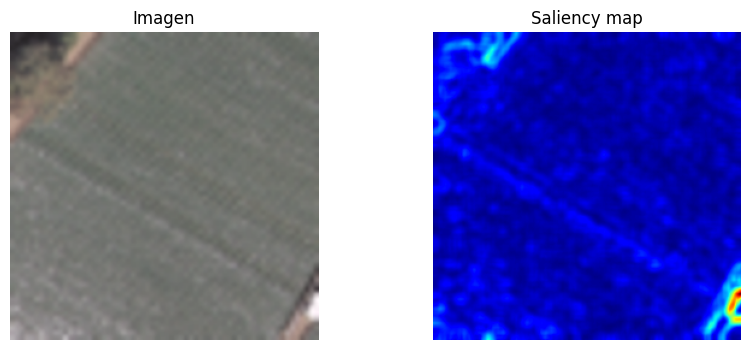

BBox: 43 13 256 256


In [64]:
# %% [6] PRUEBA DE SALIENCY
sal = compute_saliency_map(images[0])
x0, y0, x1, y1 = get_salient_region_bbox(sal)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(images[0])
plt.title("Imagen")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sal, cmap="jet")
plt.title("Saliency map")
plt.axis("off")

plt.show()
print("BBox:", x0, y0, x1, y1)

In [65]:
# %% [7] PARCHES SALIENTES
def sample_salient_patches(img_uint8, saliency, alpha=ALPHA_PATCHES, rng=None):
    if rng is None:
        rng = np.random.default_rng(SEED)

    h, w, _ = img_uint8.shape
    x0, y0, x1, y1 = get_salient_region_bbox(saliency)

    region_w = max(8, x1 - x0)
    region_h = max(8, y1 - y0)
    base_side = max(8, min(region_w, region_h))

    accepted = []
    fallback = []

    for _ in range(MAX_PATCH_TRIALS):
        side = int(rng.integers(
            max(8, int(0.3 * base_side)),
            max(9, int(0.8 * base_side) + 1)
        ))

        side = min(side, h, w, region_w, region_h)
        if side < 8:
            continue

        px = x0 if region_w - side <= 0 else int(rng.integers(x0, x1 - side + 1))
        py = y0 if region_h - side <= 0 else int(rng.integers(y0, y1 - side + 1))

        patch = img_uint8[py:py+side, px:px+side]
        patch_sal = saliency[py:py+side, px:px+side]

        c0 = side // 4
        c1 = side - c0
        center_box = patch_sal[c0:c1, c0:c1]

        mean_center_sal = float(center_box.mean())
        all_high = np.all((center_box >= 0.8) & (center_box <= 1.0))

        item = (mean_center_sal, patch.copy())

        if all_high:
            accepted.append(item)
            if len(accepted) >= alpha:
                break
        else:
            fallback.append(item)

    if len(accepted) < alpha:
        fallback = sorted(fallback, key=lambda x: x[0], reverse=True)
        accepted.extend(fallback[:alpha - len(accepted)])

    while len(accepted) < alpha:
        side = min(base_side, h, w)
        cx = (x0 + x1) // 2
        cy = (y0 + y1) // 2
        xs = max(0, min(w - side, cx - side // 2))
        ys = max(0, min(h - side, cy - side // 2))
        patch = img_uint8[ys:ys+side, xs:xs+side]
        accepted.append((0.0, patch.copy()))

    patches = [p for _, p in accepted[:alpha]]
    resized = [tf.image.resize(p, PATCH_INPUT_SIZE).numpy().astype(np.float32) for p in patches]
    return np.stack(resized, axis=0)

Shape patches: (9, 224, 224, 3)


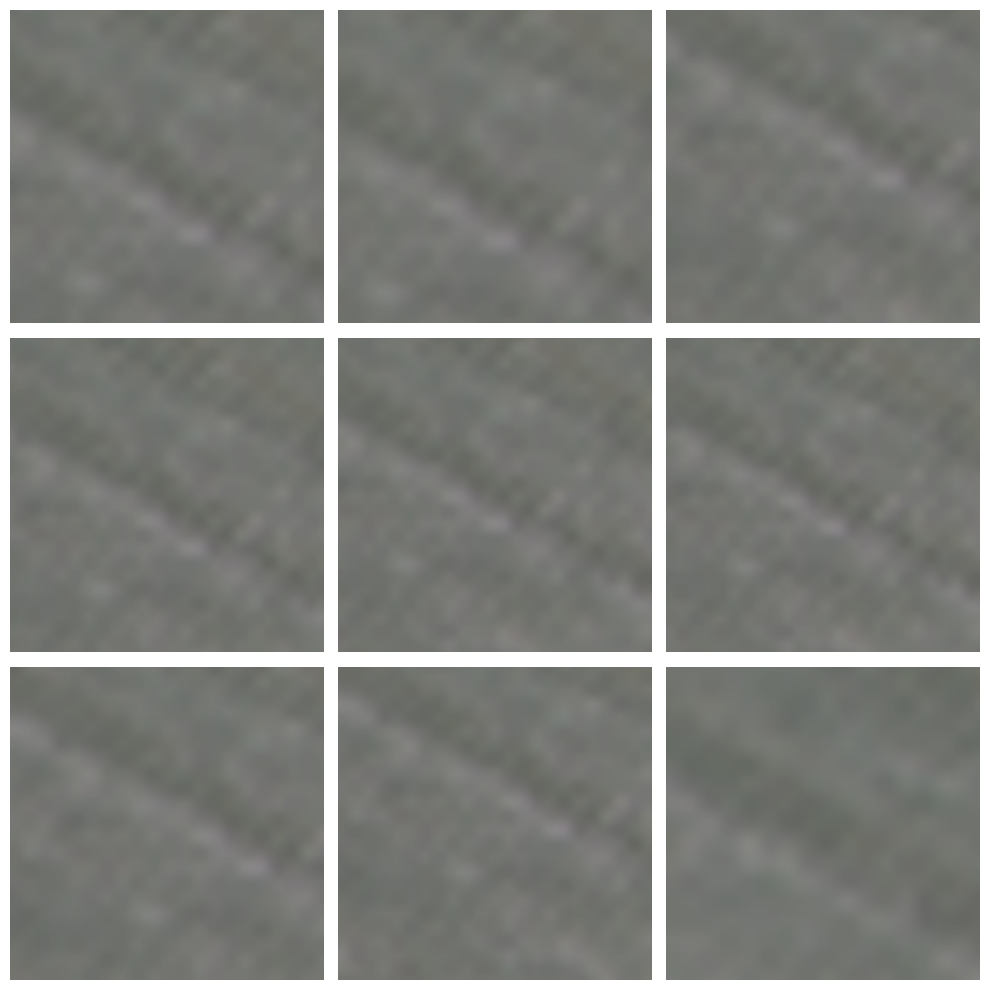

In [66]:
# %% [8] PRUEBA DE PARCHES
patches = sample_salient_patches(images[0], sal)
print("Shape patches:", patches.shape)

plt.figure(figsize=(10, 10))
for i in range(min(9, len(patches))):
    plt.subplot(3, 3, i + 1)
    plt.imshow(patches[i].astype(np.uint8))
    plt.axis("off")
plt.tight_layout()
plt.show()

In [67]:
# %% [9] RUIDOS
def add_salt_pepper_noise(img_uint8, density=0.1, rng=None):
    if rng is None:
        rng = np.random.default_rng(SEED)

    img = img_uint8.copy()
    h, w, _ = img.shape
    mask = rng.random((h, w))
    img[mask < density / 2] = 0
    img[(mask >= density / 2) & (mask < density)] = 255
    return img

def add_partial_occlusion(img_uint8, min_ratio=0.20, max_ratio=0.30, rng=None):
    if rng is None:
        rng = np.random.default_rng(SEED)

    img = img_uint8.copy()
    h, w, _ = img.shape

    ratio = float(rng.uniform(min_ratio, max_ratio))
    side_h = max(1, int(h * np.sqrt(ratio)))
    side_w = max(1, int(w * np.sqrt(ratio)))

    y = int(rng.integers(0, max(1, h - side_h + 1)))
    x = int(rng.integers(0, max(1, w - side_w + 1)))
    img[y:y+side_h, x:x+side_w] = 0
    return img

def add_mixed_noise(img_uint8, rng=None):
    if rng is None:
        rng = np.random.default_rng(SEED)

    r = rng.random()
    if r < 1/3:
        return img_uint8.copy()
    elif r < 2/3:
        return add_salt_pepper_noise(img_uint8, density=0.1, rng=rng)
    else:
        return add_partial_occlusion(img_uint8, min_ratio=0.20, max_ratio=0.30, rng=rng)

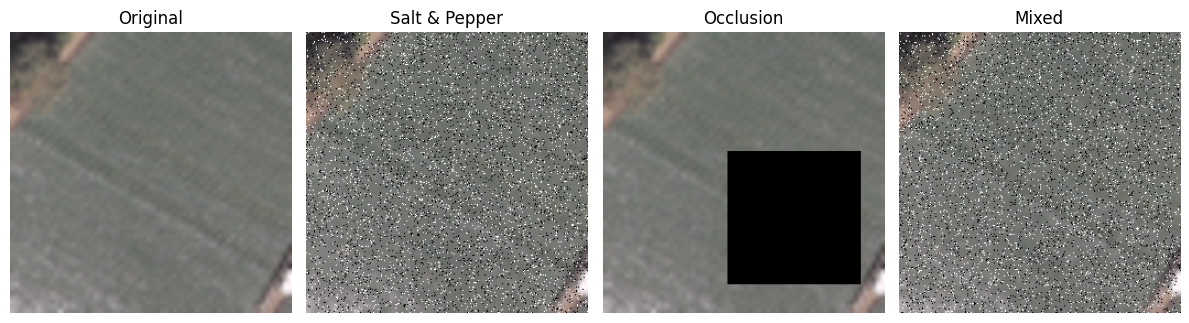

In [68]:
# %% [10] PRUEBA DE RUIDOS
rng = np.random.default_rng(42)

img_sp = add_salt_pepper_noise(images[0], rng=rng)
img_occ = add_partial_occlusion(images[0], rng=rng)
img_mix = add_mixed_noise(images[0], rng=rng)

plt.figure(figsize=(12, 4))

plt.subplot(1, 4, 1)
plt.imshow(images[0]); plt.title("Original"); plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(img_sp); plt.title("Salt & Pepper"); plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(img_occ); plt.title("Occlusion"); plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(img_mix); plt.title("Mixed"); plt.axis("off")

plt.tight_layout()
plt.show()

In [69]:
# %% [11] VGG19 Y FEATURES
def build_feature_extractor():
    base_model = VGG19(weights="imagenet", include_top=True)
    feature_extractor = tf.keras.Model(
        inputs=base_model.input,
        outputs=base_model.get_layer("fc1").output
    )
    feature_extractor.trainable = False
    return feature_extractor

FEATURE_EXTRACTOR = build_feature_extractor()

def apply_noise_mode(img_uint8, mode, rng=None):
    if mode == "clean":
        return img_uint8.copy()
    elif mode == "sp":
        return add_salt_pepper_noise(img_uint8, density=0.1, rng=rng)
    elif mode == "occ":
        return add_partial_occlusion(img_uint8, min_ratio=0.20, max_ratio=0.30, rng=rng)
    elif mode == "mixed":
        return add_mixed_noise(img_uint8, rng=rng)
    else:
        raise ValueError(f"Modo de ruido no soportado: {mode}")

def extract_scene_vector_with_mode(img_uint8, image_id=None, mode="clean"):
    cache_key = (image_id, mode)
    if image_id is not None and cache_key in FEATURE_CACHE:
        return FEATURE_CACHE[cache_key]

    mode_to_int = {"clean": 0, "sp": 1, "occ": 2, "mixed": 3}
    local_seed = SEED if image_id is None else (SEED + int(image_id) * 101 + mode_to_int[mode] * 10007)
    rng = np.random.default_rng(local_seed)

    img_mode = apply_noise_mode(img_uint8, mode=mode, rng=rng)
    sal = compute_saliency_map(img_mode)
    patches = sample_salient_patches(img_mode, saliency=sal, alpha=ALPHA_PATCHES, rng=rng)

    patches_pp = preprocess_input(patches.copy())
    feats = FEATURE_EXTRACTOR.predict(patches_pp, verbose=0)
    scene_vec = feats.mean(axis=0).astype(np.float32)
    scene_vec = scene_vec / (np.linalg.norm(scene_vec) + 1e-8)

    if image_id is not None:
        FEATURE_CACHE[cache_key] = scene_vec

    return scene_vec

In [70]:
# %% [12] PRUEBA DE FEATURES
vec = extract_scene_vector_with_mode(images[0], image_id=0, mode="clean")
print("Vector DSF shape:", vec.shape)

Vector DSF shape: (4096,)


In [71]:
# %% [13] MODELO ANTI-NOISE
class AntiNoiseTransferNet(tf.keras.Model):
    def __init__(self, n_classes):
        super().__init__()
        self.fc1 = tf.keras.layers.Dense(
            4096,
            activation="relu",
            kernel_regularizer=tf.keras.regularizers.l2(L2_LAMBDA)
        )
        self.fc2 = tf.keras.layers.Dense(
            n_classes,
            activation=None,
            kernel_regularizer=tf.keras.regularizers.l2(L2_LAMBDA)
        )

    def call(self, x, training=False, return_fc1=False):
        h = self.fc1(x)
        logits = self.fc2(h)
        if return_fc1:
            return h, logits
        return logits

model = AntiNoiseTransferNet(n_classes=len(class_names))

dummy_input = tf.zeros((1, 4096), dtype=tf.float32)
h_dummy, logits_dummy = model(dummy_input, return_fc1=True)

print("Salida FC1:", h_dummy.shape)
print("Logits:", logits_dummy.shape)
print("Variables entrenables:", len(model.trainable_variables))

Salida FC1: (1, 4096)
Logits: (1, 21)
Variables entrenables: 4


In [72]:
# %% [14] TRAINING Y CROSS-VALIDATION
def balanced_subset(indices, labels, max_total, seed=42):
    """
    Selecciona una submuestra aproximadamente balanceada por clase.
    """
    indices = np.asarray(indices)

    if max_total is None or max_total >= len(indices):
        return indices

    rng = np.random.default_rng(seed)
    y_sub = labels[indices]
    classes = np.unique(y_sub)

    per_class = max(1, max_total // len(classes))

    selected = []
    leftovers = []

    for c in classes:
        c_idx = indices[y_sub == c].copy()
        rng.shuffle(c_idx)

        take = min(per_class, len(c_idx))
        selected.extend(c_idx[:take].tolist())

        if take < len(c_idx):
            leftovers.extend(c_idx[take:].tolist())

    remaining = max_total - len(selected)

    if remaining > 0 and len(leftovers) > 0:
        leftovers = np.array(leftovers)
        rng.shuffle(leftovers)
        selected.extend(leftovers[:remaining].tolist())

    selected = np.array(selected, dtype=int)
    rng.shuffle(selected)
    return selected


def build_training_pairs(images, labels, indices):
    clean_vectors = []
    noisy_vectors = []
    y_pairs = []

    for idx in tqdm(indices, desc="Extrayendo train pairs"):
        img = images[idx]
        label = labels[idx]

        clean_vec = extract_scene_vector_with_mode(img, image_id=idx, mode="clean")

        for noise_mode in ["sp", "occ", "mixed"]:
            noisy_vec = extract_scene_vector_with_mode(img, image_id=idx, mode=noise_mode)
            clean_vectors.append(clean_vec)
            noisy_vectors.append(noisy_vec)
            y_pairs.append(label)

    return (
        np.asarray(clean_vectors, dtype=np.float32),
        np.asarray(noisy_vectors, dtype=np.float32),
        np.asarray(y_pairs, dtype=np.int32),
    )


def build_test_features(images, labels, indices):
    X = []
    y = []

    for idx in tqdm(indices, desc="Extrayendo test features"):
        vec = extract_scene_vector_with_mode(images[idx], image_id=idx, mode="clean")
        X.append(vec)
        y.append(labels[idx])

    return np.asarray(X, dtype=np.float32), np.asarray(y, dtype=np.int32)


loss_ce_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)


def compute_joint_loss(model, x_clean, x_noisy, y_true):
    h_clean, logits_clean = model(x_clean, training=True, return_fc1=True)
    h_noisy, _ = model(x_noisy, training=True, return_fc1=True)

    ce = loss_ce_fn(y_true, logits_clean)
    anti = tf.reduce_mean(tf.reduce_sum(tf.square(h_clean - h_noisy), axis=1))

    if len(model.losses) > 0:
        reg = tf.add_n(model.losses)
    else:
        reg = tf.constant(0.0, dtype=tf.float32)

    total = ce + BETA_ANTI * anti + reg
    return total, ce, anti, reg


def train_step(model, optimizer, x_clean, x_noisy, y_true):
    with tf.GradientTape() as tape:
        total, ce, anti, reg = compute_joint_loss(model, x_clean, x_noisy, y_true)

    grads = tape.gradient(total, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    _, logits = model(x_clean, training=False, return_fc1=True)
    preds = tf.argmax(logits, axis=1, output_type=tf.int32)
    acc = tf.reduce_mean(tf.cast(tf.equal(preds, y_true), tf.float32))

    return total, ce, anti, reg, acc


def evaluate_model(model, X_test, y_test):
    X_test = tf.convert_to_tensor(X_test, dtype=tf.float32)
    logits = model(X_test, training=False)
    preds = tf.argmax(logits, axis=1).numpy()
    acc = accuracy_score(y_test, preds)
    return acc, preds


def make_batches(x_clean, x_noisy, y, batch_size):
    n = len(y)
    idx = np.arange(n)
    np.random.shuffle(idx)

    for start in range(0, n, batch_size):
        batch_idx = idx[start:start + batch_size]
        yield x_clean[batch_idx], x_noisy[batch_idx], y[batch_idx]


def evaluate_loss_and_accuracy(model, X_eval, y_eval, batch_size=128):
    losses = []
    accs = []

    for start in range(0, len(y_eval), batch_size):
        xb = tf.convert_to_tensor(X_eval[start:start + batch_size], dtype=tf.float32)
        yb = tf.convert_to_tensor(y_eval[start:start + batch_size], dtype=tf.int32)

        _, logits = model(xb, training=False, return_fc1=True)
        ce = loss_ce_fn(yb, logits)

        preds = tf.argmax(logits, axis=1, output_type=tf.int32)
        acc = tf.reduce_mean(tf.cast(tf.equal(preds, yb), tf.float32))

        losses.append(float(ce.numpy()))
        accs.append(float(acc.numpy()))

    return float(np.mean(losses)), float(np.mean(accs))


def run_five_fold_cv(images, labels, class_names):
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

    fold_accuracies = []
    final_fold_true = None
    final_fold_pred = None

    for fold, (train_idx, test_idx) in enumerate(skf.split(images, labels), start=1):
        print("=" * 70)
        print(f"FOLD {fold}/{N_FOLDS}")

        # Submuestreo balanceado SOLO para debug
        if MAX_TRAIN_IMAGES_PER_FOLD is not None:
            train_idx = balanced_subset(
                train_idx, labels, MAX_TRAIN_IMAGES_PER_FOLD, seed=SEED + fold
            )

        if MAX_TEST_IMAGES_PER_FOLD is not None:
            test_idx = balanced_subset(
                test_idx, labels, MAX_TEST_IMAGES_PER_FOLD, seed=SEED + 100 + fold
            )

        # Split interno train/val
        train_sub_idx, val_sub_idx = train_test_split(
            train_idx,
            test_size=0.15,
            stratify=labels[train_idx],
            random_state=SEED + fold
        )

        train_unique = np.unique(labels[train_sub_idx])
        val_unique = np.unique(labels[val_sub_idx])
        test_unique = np.unique(labels[test_idx])

        print("Clases en train subset:", len(train_unique), "de", len(class_names))
        print("Clases en val subset:", len(val_unique), "de", len(class_names))
        print("Clases en test subset:", len(test_unique), "de", len(class_names))

        Xc_train, Xn_train, y_train = build_training_pairs(images, labels, train_sub_idx)
        X_val, y_val = build_test_features(images, labels, val_sub_idx)
        X_test, y_test = build_test_features(images, labels, test_idx)

        print(f"Train pairs: {len(y_train)}")
        print(f"Val scenes: {len(y_val)}")
        print(f"Test scenes: {len(y_test)}")

        model = AntiNoiseTransferNet(n_classes=len(class_names))
        _ = model(tf.zeros((1, 4096), dtype=tf.float32), training=False)

        optimizer = tf.keras.optimizers.SGD(learning_rate=LR, momentum=0.9)

        history_loss = []
        history_acc = []
        history_val_loss = []
        history_val_acc = []

        for epoch in range(1, EPOCHS + 1):
            epoch_losses = []
            epoch_accs = []
            epoch_ce = []
            epoch_anti = []
            epoch_reg = []

            for xb_clean, xb_noisy, yb in make_batches(Xc_train, Xn_train, y_train, BATCH_SIZE):
                xb_clean = tf.convert_to_tensor(xb_clean, dtype=tf.float32)
                xb_noisy = tf.convert_to_tensor(xb_noisy, dtype=tf.float32)
                yb = tf.convert_to_tensor(yb, dtype=tf.int32)

                total, ce, anti, reg, acc = train_step(model, optimizer, xb_clean, xb_noisy, yb)

                epoch_losses.append(float(total.numpy()))
                epoch_accs.append(float(acc.numpy()))
                epoch_ce.append(float(ce.numpy()))
                epoch_anti.append(float(anti.numpy()))
                epoch_reg.append(float(reg.numpy()))

            mean_loss = float(np.mean(epoch_losses))
            mean_acc = float(np.mean(epoch_accs))
            mean_ce = float(np.mean(epoch_ce))
            mean_anti = float(np.mean(epoch_anti))
            mean_reg = float(np.mean(epoch_reg))

            val_loss, val_acc = evaluate_loss_and_accuracy(model, X_val, y_val)

            history_loss.append(mean_loss)
            history_acc.append(mean_acc)
            history_val_loss.append(val_loss)
            history_val_acc.append(val_acc)

            print(
                f"Epoch {epoch:02d}/{EPOCHS} - "
                f"total={mean_loss:.4f} - ce={mean_ce:.4f} - "
                f"anti={mean_anti:.4f} - reg={mean_reg:.4f} - "
                f"train_acc={mean_acc:.4f} - "
                f"val_loss={val_loss:.4f} - val_acc={val_acc:.4f}"
            )

        test_acc, y_pred = evaluate_model(model, X_test, y_test)
        fold_accuracies.append(test_acc)

        print(f"[Fold {fold}] Test Accuracy = {test_acc * 100:.2f}%")

        final_fold_true = y_test
        final_fold_pred = y_pred

        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        plt.plot(history_acc, label="Train Accuracy")
        plt.plot(history_val_acc, label="Validation Accuracy")
        plt.title("Model Accuracy over Epochs")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(history_loss, label="Train Loss")
        plt.plot(history_val_loss, label="Validation Loss")
        plt.title("Model Loss over Epochs")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()

        plt.tight_layout()
        plt.show()

    print("=" * 70)
    print("RESULTADOS")
    print(f"Accuracies: {[round(a * 100, 2) for a in fold_accuracies]}")
    print(f"Mean Accuracy: {np.mean(fold_accuracies) * 100:.2f}%")
    print(f"Std Accuracy:  {np.std(fold_accuracies) * 100:.2f}%")

    all_labels = list(range(len(class_names)))

    cm = confusion_matrix(final_fold_true, final_fold_pred, labels=all_labels)
    plt.figure(figsize=(14, 12))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title("Confusion Matrix - Último Fold")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    print("\nClassification Report - Último Fold")
    print(
        classification_report(
            final_fold_true,
            final_fold_pred,
            labels=all_labels,
            target_names=class_names,
            zero_division=0
        )
    )

Número de imágenes: 2100
Número de clases: 21
Shape imágenes: (2100, 256, 256, 3)
Primeras clases: ['agricultural', 'airplane', 'baseballdiamond', 'beach', 'buildings']
RUN_MODE: full
FOLD 1/5
Clases en train subset: 21 de 21
Clases en val subset: 21 de 21
Clases en test subset: 21 de 21


Extrayendo train pairs:   0%|          | 0/1428 [00:00<?, ?it/s]

Extrayendo test features:   0%|          | 0/252 [00:00<?, ?it/s]

Extrayendo test features:   0%|          | 0/420 [00:00<?, ?it/s]

Train pairs: 4284
Val scenes: 252
Test scenes: 420
Epoch 01/20 - total=3.4068 - ce=2.9935 - anti=0.3533 - reg=0.4129 - train_acc=0.2839 - val_loss=2.9308 - val_acc=0.4558
Epoch 02/20 - total=3.2598 - ce=2.8479 - anti=0.5212 - reg=0.4113 - train_acc=0.4902 - val_loss=2.7577 - val_acc=0.4962
Epoch 03/20 - total=3.0326 - ce=2.6213 - anti=0.7906 - reg=0.4106 - train_acc=0.5611 - val_loss=2.4929 - val_acc=0.5522
Epoch 04/20 - total=2.7279 - ce=2.3157 - anti=1.2059 - reg=0.4110 - train_acc=0.5787 - val_loss=2.1817 - val_acc=0.5679
Epoch 05/20 - total=2.4171 - ce=2.0031 - anti=1.7160 - reg=0.4123 - train_acc=0.6089 - val_loss=1.9040 - val_acc=0.6198
Epoch 06/20 - total=2.1630 - ce=1.7467 - anti=2.2418 - reg=0.4140 - train_acc=0.6361 - val_loss=1.6902 - val_acc=0.6476
Epoch 07/20 - total=1.9669 - ce=1.5484 - anti=2.7290 - reg=0.4158 - train_acc=0.6632 - val_loss=1.5211 - val_acc=0.6597
Epoch 08/20 - total=1.8188 - ce=1.3981 - anti=3.1591 - reg=0.4175 - train_acc=0.6863 - val_loss=1.3941 - val_

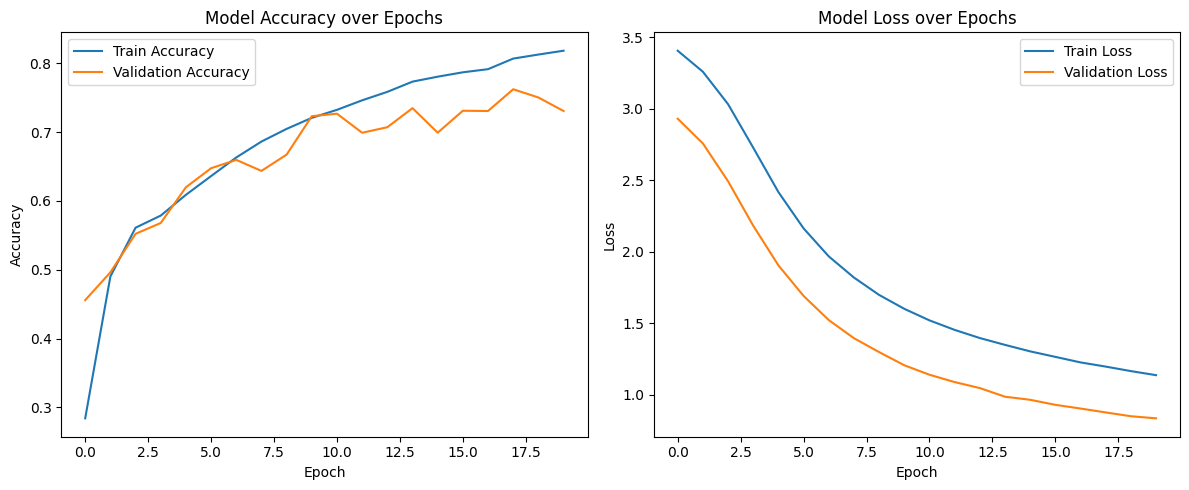

FOLD 2/5
Clases en train subset: 21 de 21
Clases en val subset: 21 de 21
Clases en test subset: 21 de 21


Extrayendo train pairs:   0%|          | 0/1428 [00:00<?, ?it/s]

Extrayendo test features:   0%|          | 0/252 [00:00<?, ?it/s]

Extrayendo test features:   0%|          | 0/420 [00:00<?, ?it/s]

Train pairs: 4284
Val scenes: 252
Test scenes: 420
Epoch 01/20 - total=3.4066 - ce=2.9934 - anti=0.3466 - reg=0.4129 - train_acc=0.2650 - val_loss=2.9262 - val_acc=0.5115
Epoch 02/20 - total=3.2597 - ce=2.8478 - anti=0.5142 - reg=0.4113 - train_acc=0.4940 - val_loss=2.7452 - val_acc=0.5512
Epoch 03/20 - total=3.0319 - ce=2.6204 - anti=0.7897 - reg=0.4106 - train_acc=0.5416 - val_loss=2.4697 - val_acc=0.5869
Epoch 04/20 - total=2.7267 - ce=2.3145 - anti=1.2042 - reg=0.4110 - train_acc=0.5770 - val_loss=2.1467 - val_acc=0.5474
Epoch 05/20 - total=2.4189 - ce=2.0048 - anti=1.7188 - reg=0.4123 - train_acc=0.6022 - val_loss=1.8597 - val_acc=0.6069
Epoch 06/20 - total=2.1660 - ce=1.7497 - anti=2.2558 - reg=0.4141 - train_acc=0.6294 - val_loss=1.6388 - val_acc=0.6544
Epoch 07/20 - total=1.9726 - ce=1.5540 - anti=2.7417 - reg=0.4158 - train_acc=0.6667 - val_loss=1.4722 - val_acc=0.6820
Epoch 08/20 - total=1.8268 - ce=1.4061 - anti=3.1768 - reg=0.4175 - train_acc=0.6803 - val_loss=1.3409 - val_

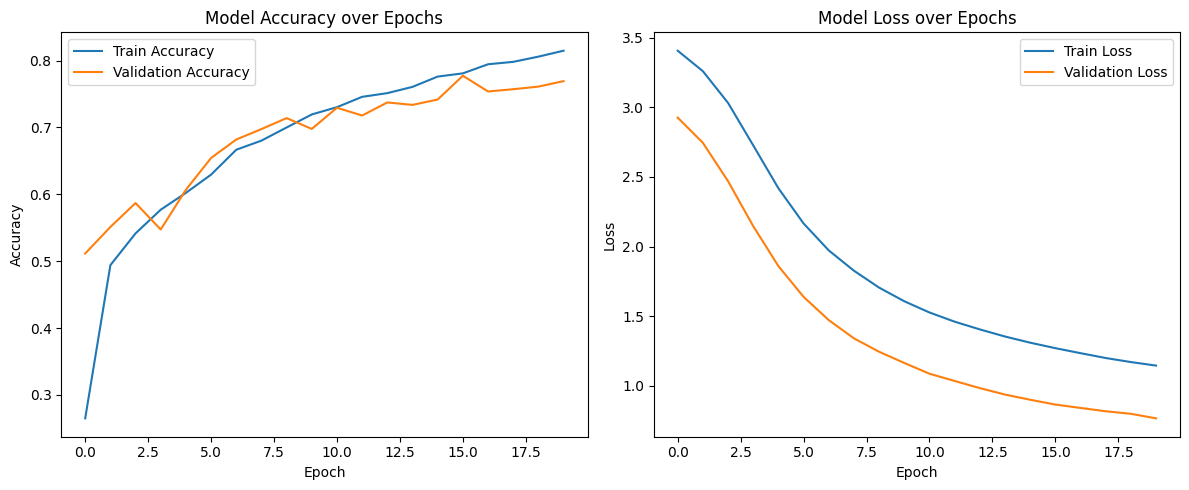

FOLD 3/5
Clases en train subset: 21 de 21
Clases en val subset: 21 de 21
Clases en test subset: 21 de 21


Extrayendo train pairs:   0%|          | 0/1428 [00:00<?, ?it/s]

Extrayendo test features:   0%|          | 0/252 [00:00<?, ?it/s]

Extrayendo test features:   0%|          | 0/420 [00:00<?, ?it/s]

Train pairs: 4284
Val scenes: 252
Test scenes: 420
Epoch 01/20 - total=3.4048 - ce=2.9915 - anti=0.3507 - reg=0.4130 - train_acc=0.2708 - val_loss=2.9289 - val_acc=0.5168
Epoch 02/20 - total=3.2541 - ce=2.8421 - anti=0.5261 - reg=0.4114 - train_acc=0.5297 - val_loss=2.7515 - val_acc=0.5089
Epoch 03/20 - total=3.0202 - ce=2.6086 - anti=0.8099 - reg=0.4108 - train_acc=0.5633 - val_loss=2.4802 - val_acc=0.5964
Epoch 04/20 - total=2.7079 - ce=2.2954 - anti=1.2324 - reg=0.4112 - train_acc=0.5821 - val_loss=2.1607 - val_acc=0.5525
Epoch 05/20 - total=2.3957 - ce=1.9813 - anti=1.7676 - reg=0.4126 - train_acc=0.6037 - val_loss=1.8772 - val_acc=0.6352
Epoch 06/20 - total=2.1439 - ce=1.7273 - anti=2.3013 - reg=0.4143 - train_acc=0.6449 - val_loss=1.6654 - val_acc=0.6236
Epoch 07/20 - total=1.9552 - ce=1.5363 - anti=2.7974 - reg=0.4161 - train_acc=0.6682 - val_loss=1.5029 - val_acc=0.6312
Epoch 08/20 - total=1.8095 - ce=1.3886 - anti=3.2246 - reg=0.4177 - train_acc=0.6900 - val_loss=1.3788 - val_

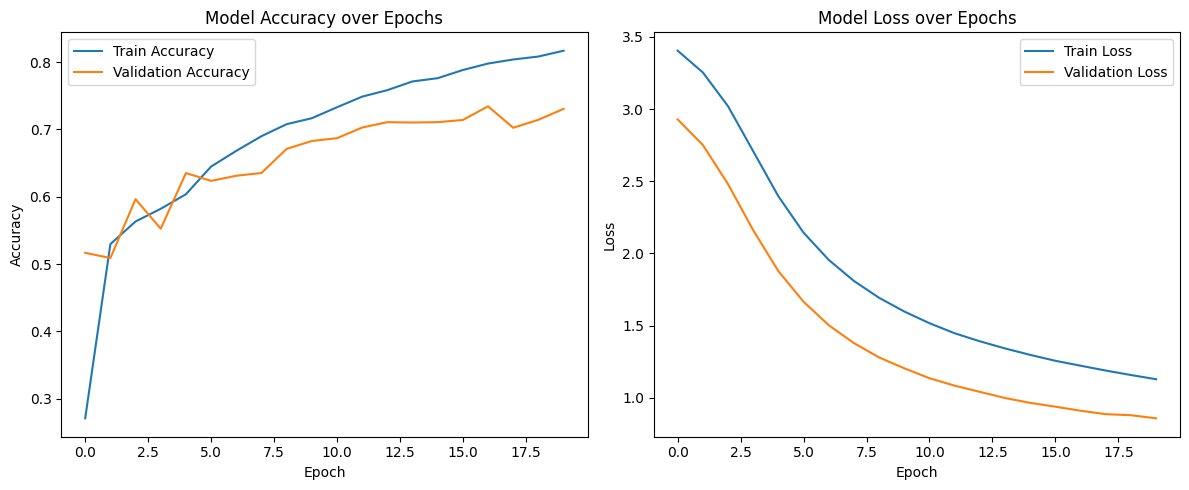

FOLD 4/5
Clases en train subset: 21 de 21
Clases en val subset: 21 de 21
Clases en test subset: 21 de 21


Extrayendo train pairs:   0%|          | 0/1428 [00:00<?, ?it/s]

Extrayendo test features:   0%|          | 0/252 [00:00<?, ?it/s]

Extrayendo test features:   0%|          | 0/420 [00:00<?, ?it/s]

Train pairs: 4284
Val scenes: 252
Test scenes: 420
Epoch 01/20 - total=3.4079 - ce=2.9947 - anti=0.3635 - reg=0.4129 - train_acc=0.2986 - val_loss=2.9355 - val_acc=0.4446
Epoch 02/20 - total=3.2617 - ce=2.8499 - anti=0.5296 - reg=0.4112 - train_acc=0.4988 - val_loss=2.7663 - val_acc=0.5435
Epoch 03/20 - total=3.0345 - ce=2.6232 - anti=0.8063 - reg=0.4105 - train_acc=0.5693 - val_loss=2.5029 - val_acc=0.5359
Epoch 04/20 - total=2.7272 - ce=2.3150 - anti=1.2403 - reg=0.4109 - train_acc=0.5843 - val_loss=2.1880 - val_acc=0.5476
Epoch 05/20 - total=2.4113 - ce=1.9973 - anti=1.7755 - reg=0.4123 - train_acc=0.6121 - val_loss=1.9118 - val_acc=0.5911
Epoch 06/20 - total=2.1578 - ce=1.7415 - anti=2.3233 - reg=0.4140 - train_acc=0.6411 - val_loss=1.6974 - val_acc=0.5869
Epoch 07/20 - total=1.9617 - ce=1.5431 - anti=2.8175 - reg=0.4158 - train_acc=0.6766 - val_loss=1.5328 - val_acc=0.6347
Epoch 08/20 - total=1.8102 - ce=1.3895 - anti=3.2672 - reg=0.4175 - train_acc=0.6963 - val_loss=1.4153 - val_

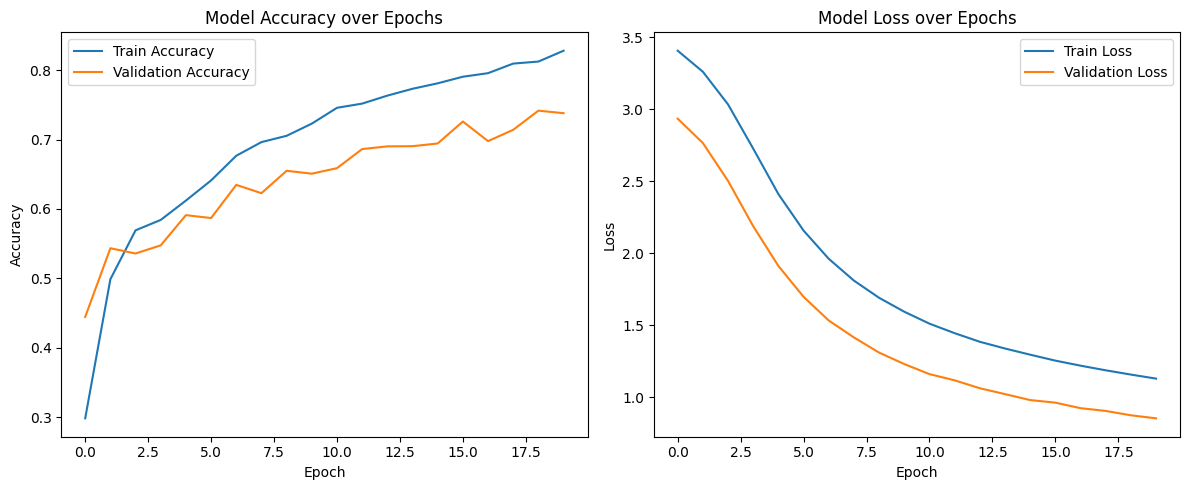

FOLD 5/5
Clases en train subset: 21 de 21
Clases en val subset: 21 de 21
Clases en test subset: 21 de 21


Extrayendo train pairs:   0%|          | 0/1428 [00:00<?, ?it/s]

Extrayendo test features:   0%|          | 0/252 [00:00<?, ?it/s]

Extrayendo test features:   0%|          | 0/420 [00:00<?, ?it/s]

Train pairs: 4284
Val scenes: 252
Test scenes: 420
Epoch 01/20 - total=3.4045 - ce=2.9913 - anti=0.3460 - reg=0.4128 - train_acc=0.2660 - val_loss=2.9274 - val_acc=0.4846
Epoch 02/20 - total=3.2571 - ce=2.8454 - anti=0.5208 - reg=0.4112 - train_acc=0.4745 - val_loss=2.7495 - val_acc=0.5950
Epoch 03/20 - total=3.0273 - ce=2.6160 - anti=0.8006 - reg=0.4105 - train_acc=0.5591 - val_loss=2.4768 - val_acc=0.5591
Epoch 04/20 - total=2.7188 - ce=2.3066 - anti=1.2259 - reg=0.4109 - train_acc=0.5795 - val_loss=2.1530 - val_acc=0.5635
Epoch 05/20 - total=2.4091 - ce=1.9951 - anti=1.7501 - reg=0.4123 - train_acc=0.6099 - val_loss=1.8672 - val_acc=0.5993
Epoch 06/20 - total=2.1566 - ce=1.7403 - anti=2.2864 - reg=0.4140 - train_acc=0.6350 - val_loss=1.6481 - val_acc=0.6226
Epoch 07/20 - total=1.9658 - ce=1.5472 - anti=2.7793 - reg=0.4158 - train_acc=0.6656 - val_loss=1.4791 - val_acc=0.6505
Epoch 08/20 - total=1.8175 - ce=1.3968 - anti=3.2056 - reg=0.4175 - train_acc=0.6803 - val_loss=1.3493 - val_

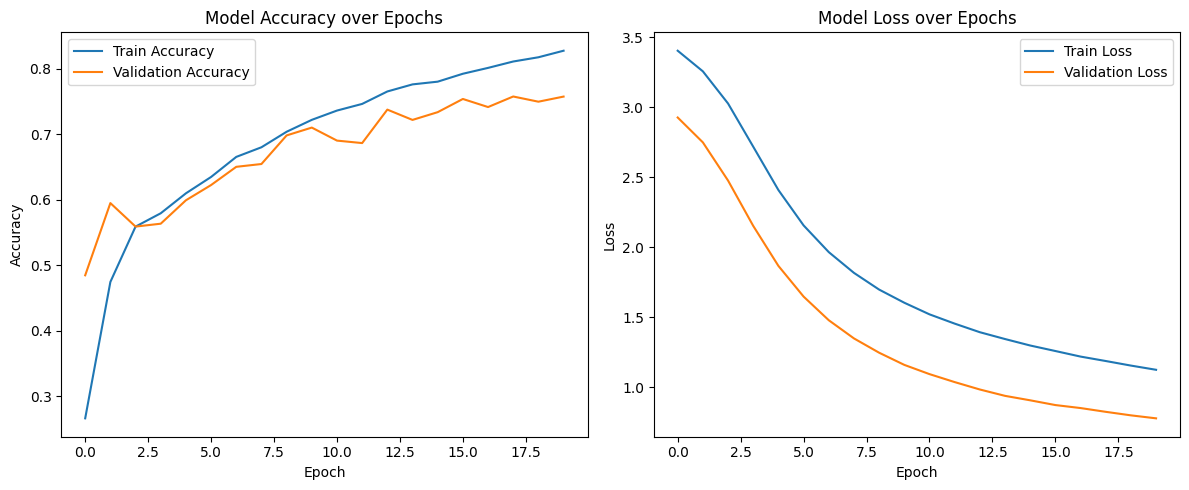

RESULTADOS
Accuracies: [76.43, 75.0, 73.33, 76.43, 73.33]
Mean Accuracy: 74.90%
Std Accuracy:  1.39%


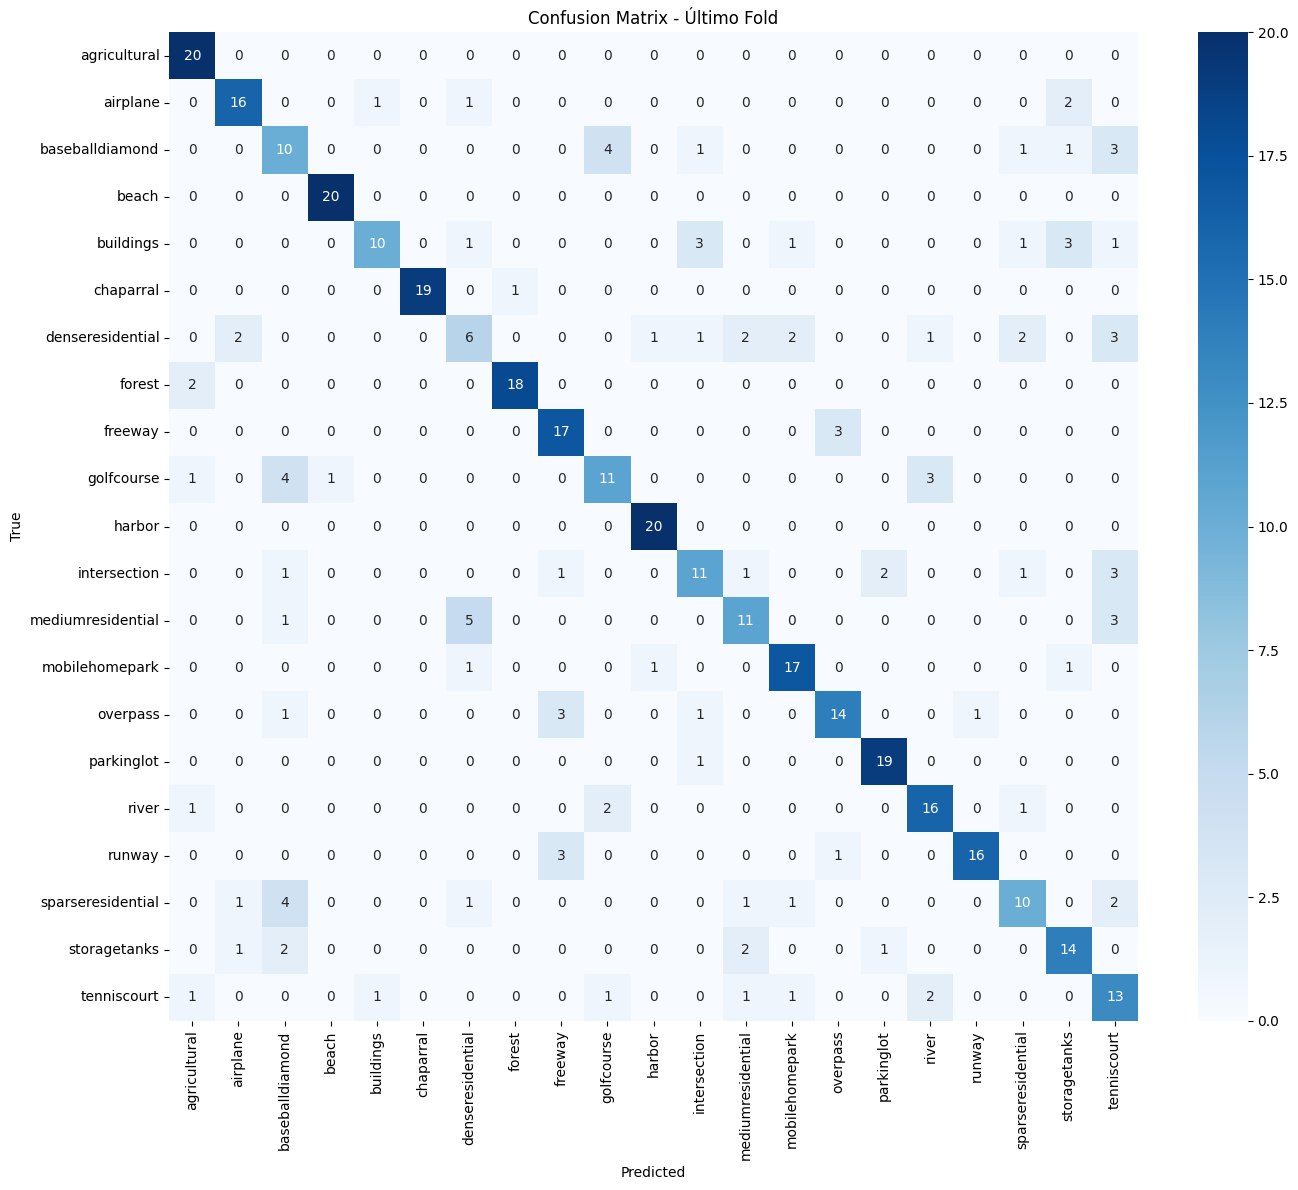


Classification Report - Último Fold
                   precision    recall  f1-score   support

     agricultural       0.80      1.00      0.89        20
         airplane       0.80      0.80      0.80        20
  baseballdiamond       0.43      0.50      0.47        20
            beach       0.95      1.00      0.98        20
        buildings       0.83      0.50      0.62        20
        chaparral       1.00      0.95      0.97        20
 denseresidential       0.40      0.30      0.34        20
           forest       0.95      0.90      0.92        20
          freeway       0.71      0.85      0.77        20
       golfcourse       0.61      0.55      0.58        20
           harbor       0.91      1.00      0.95        20
     intersection       0.61      0.55      0.58        20
mediumresidential       0.61      0.55      0.58        20
   mobilehomepark       0.77      0.85      0.81        20
         overpass       0.78      0.70      0.74        20
       parkinglot 

In [73]:
# %% [15] MAIN FINAL
print("Número de imágenes:", len(images))
print("Número de clases:", len(class_names))
print("Shape imágenes:", images.shape)
print("Primeras clases:", class_names[:5])
print("RUN_MODE:", RUN_MODE)

run_five_fold_cv(images, labels, class_names)